In [11]:
#the command below are used to check for the versuion of libreary that are included in the 
#project.


import sys 
print('Python : {}'.format(sys.version))
import pandas
print('pandas : {}'.format(pandas.__version__))
import numpy
print('numpy : {}'.format(numpy.__version__))
import matplotlib
print('matplotlib : {}'.format(matplotlib.__version__))
import sklearn
print('sklearn : {}'.format(sklearn.__version__))
import scipy
print('scipy : {}'.format(scipy.__version__))



Python : 3.14.4 (main, Apr  8 2026, 17:48:49) [GCC 15.2.1 20260209]
pandas : 3.0.2
numpy : 2.4.4
matplotlib : 3.10.9
sklearn : 1.8.0
scipy : 1.17.1


In [12]:
 #import the require libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn


In [23]:

#crim: Per capita crime rate by town.
#zn: Proportion of large residential lots (over 25,000 sq. ft.).
#indus: Proportion of non-retail business acres per town.
#Chas: Binary variable indicating if the property is near Charles River (1 for yes, 0 for no).
#nox: Concentration of nitrogen oxides in the air.
#rm: Average number of rooms per dwelling.
#age: Proportion of old owner-occupied units built before 1940.
#dis: Weighted distances to Boston employment centers.
#rad: Index of accessibility to radial highways.
#tax: Property tax rate per $10,000.

df = pd.read_csv("BostonHousing.csv")
print(df.head(5))

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


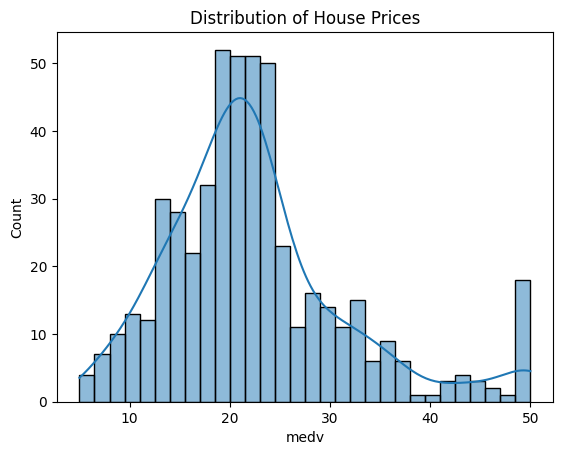

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["medv"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()


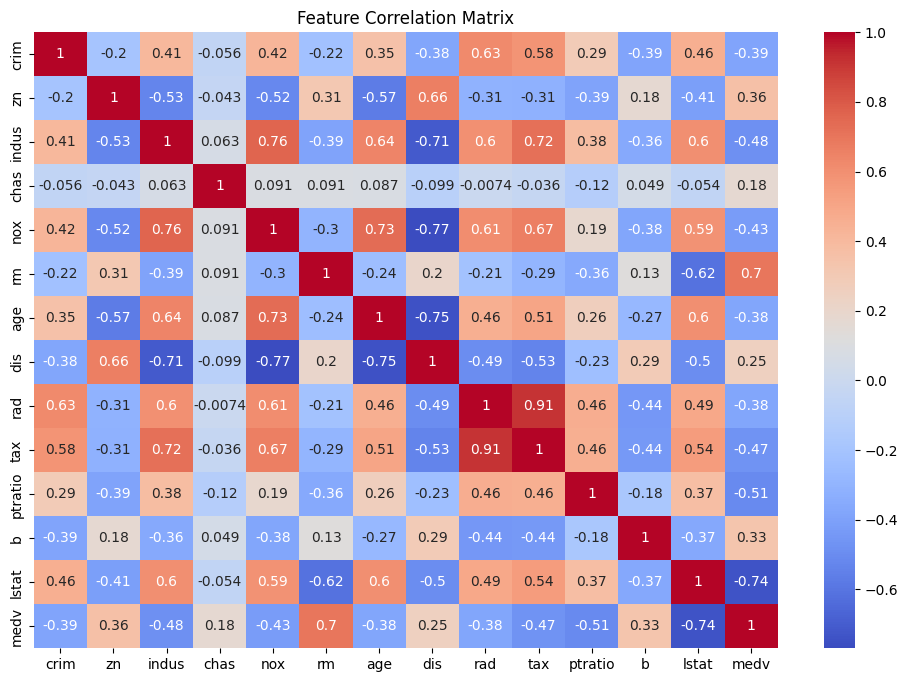

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()


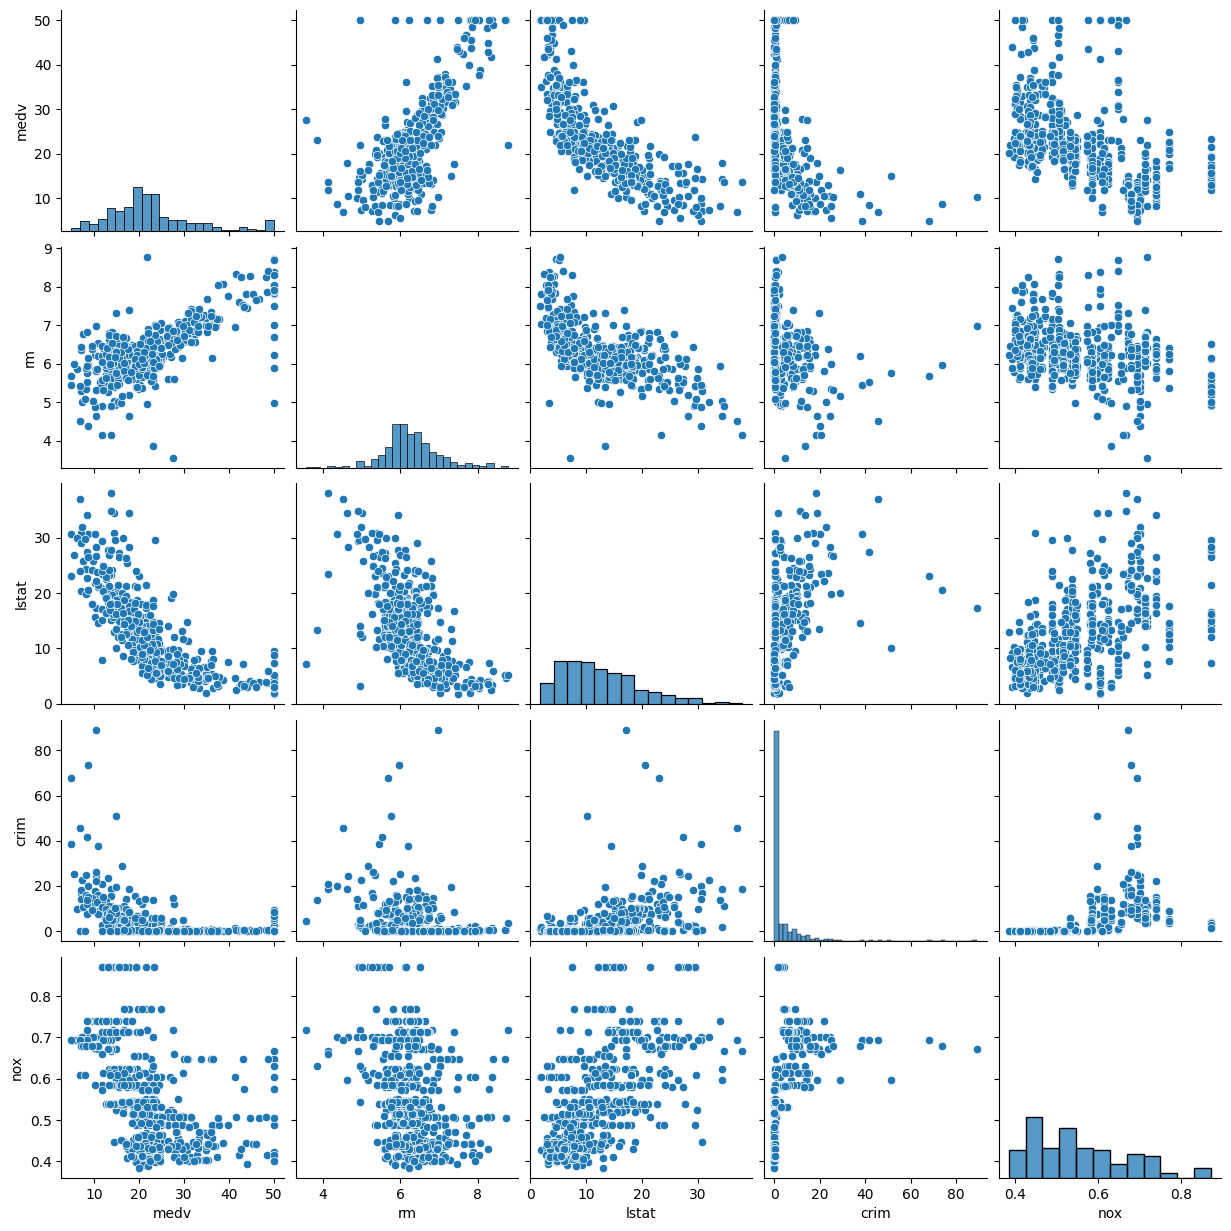

In [21]:
#
sns.pairplot(df[["medv","rm","lstat","crim","nox"]])
plt.show()

In [46]:
from sklearn.model_selection import train_test_split

#confirming if the value which are empty are there
print(df.isnull().sum())

#filling nul value with median values from  respective columns
df = df.fillna(df.median())
features = ["lstat", "rm", "ptratio", "dis", "nox"]

x = df[features]
y = df["medv"]


x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [48]:

#this shape of the data used  for training
print(x_train.shape)

#this is the data that will be used to train
print(x_test.shape)


(404, 5)
(102, 5)


In [49]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
y_pred = model.predict(x_test)

In [51]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 25.40192038756929
R2 Score: 0.6536123012768155
